# **8.2. 인공지능과 가위바위보 하기 [프로젝트]**

<br>

## **2-1. 미니 프로젝트 : 가위바위보 분류기를 만들자**

---

#### **라이브러리 버전을 확인해 봅니다**

In [1]:
import tensorflow as tf
import numpy as np

print(tf.__version__)
print(np.__version__)

2.19.0
2.0.2


<br>

#### **데이터를 준비하자**

(중략)

<br>

#### **데이터 불러오기 + Resize 하기**

In [2]:
import os
import zipfile
import shutil
from google.colab import drive

In [3]:
# 구글 드라이브 마운트
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 1. 경로 설정 및 초기화
drive_root = '/content/drive/MyDrive/DS_8th/08_딥러닝 알아보기/data'
base_path = '/content/rock_scissor_paper'
versions = ['data_v1', 'data_v2', 'data_v3', 'data_v4']
zip_files = ['class1.zip', 'class2.zip', 'class3.zip'] # 가위, 바위, 보 순서
categories = ['scissor', 'rock', 'paper']

In [5]:
# 기존 폴더 삭제 후 재생성 (데이터 무결성 확보)
if os.path.exists(base_path):
    shutil.rmtree(base_path)

for cat in categories:
    os.makedirs(os.path.join(base_path, cat), exist_ok=True)

In [6]:
# 통합 압축 해제

In [7]:
print("--- v1~v4 데이터 중복 방지 통합 압축 해제 중... ---")
for v in versions:
    for zip_name, cat in zip(zip_files, categories):
        zip_src = os.path.join(drive_root, v, zip_name)
        target_dir = os.path.join(base_path, cat)

        if os.path.exists(zip_src):
            with zipfile.ZipFile(zip_src, 'r') as zip_ref:
                for file_info in zip_ref.infolist():
                    if not file_info.is_dir():
                        # 경로를 제외한 순수 파일명 추출
                        original_name = os.path.basename(file_info.filename)
                        if original_name: # 빈 이름 방지
                            # 파일명 앞에 v1_, v2_, v3_, v4_를 붙여서 중복 차단
                            file_info.filename = f"{v}_{original_name}"
                            zip_ref.extract(file_info, target_dir)
            print(f"{v}/{zip_name} 해제 완료")
        else:
            print(f"파일을 찾을 수 없습니다: {zip_src}")

--- v1~v4 데이터 중복 방지 통합 압축 해제 중... ---
data_v1/class1.zip 해제 완료
data_v1/class2.zip 해제 완료
data_v1/class3.zip 해제 완료
data_v2/class1.zip 해제 완료
data_v2/class2.zip 해제 완료
data_v2/class3.zip 해제 완료
data_v3/class1.zip 해제 완료
data_v3/class2.zip 해제 완료
data_v3/class3.zip 해제 완료
data_v4/class1.zip 해제 완료
data_v4/class2.zip 해제 완료
data_v4/class3.zip 해제 완료


In [8]:
# 3. 최종 개수 확인 리포트

In [9]:
print("--- 최종 통합 결과 리포트 ---")
total_count = 0
for cat in categories:
    cat_path = os.path.join(base_path, cat)
    files = [f for f in os.listdir(cat_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f" - {cat.upper()} 폴더 파일 수: {len(files)}개")
    total_count += len(files)

print(f"\n총 {len(versions)}개 버전의 데이터가 통합되었습니다.")
print(f"전체 데이터 합계: {total_count}개")

--- 최종 통합 결과 리포트 ---
 - SCISSOR 폴더 파일 수: 1099개
 - ROCK 폴더 파일 수: 1100개
 - PAPER 폴더 파일 수: 1100개

총 4개 버전의 데이터가 통합되었습니다.
전체 데이터 합계: 3299개


In [10]:
# 통합 후 데이터 개수 확인

In [11]:
for cat in categories:
    path = os.path.join(base_path, cat)
    files = os.listdir(path)
    print(f"{cat} 폴더 내 파일 수: {len(files)}개")

scissor 폴더 내 파일 수: 1099개
rock 폴더 내 파일 수: 1100개
paper 폴더 내 파일 수: 1100개


이제 가위 이미지를 불러와서 **64x64** 사이즈로 변경할 겁니다.

In [12]:
from PIL import Image
import glob
import os

print("PIL 라이브러리 import 완료!")

PIL 라이브러리 import 완료!


In [13]:
def resize_images(img_path):
    # 해당 경로에 있는 모든 jpg 파일을 가져옴.
    images = glob.glob(img_path + "/*.jpg")

    print(len(images), f" images in {img_path} to be resized.")

    # 파일마다 모두 64x64 사이즈로 바꾸어 저장
    target_size = (64, 64)
    for img in images:
        old_img = Image.open(img)
        # Image.ANTIALIAS 대신 최신 표준인 Image.Resampling.LANCZOS 사용
        new_img = old_img.resize(target_size, Image.Resampling.LANCZOS)
        new_img.save(img, "JPEG")

    print(len(images), " images resized.")

In [14]:
# 가위 이미지가 저장된 디렉토리 아래의 모든 jpg 파일을 읽어들여서

In [15]:
image_dir_path = "/content/rock_scissor_paper/scissor"
resize_images(image_dir_path)

print("가위 이미지 resize 완료!")

1099  images in /content/rock_scissor_paper/scissor to be resized.
1099  images resized.
가위 이미지 resize 완료!


In [16]:
# 2. 바위(rock) 이미지 리사이즈 (추가)

In [17]:
image_dir_path = "/content/rock_scissor_paper/rock"
resize_images(image_dir_path)

print("바위 이미지 resize 완료!")

1100  images in /content/rock_scissor_paper/rock to be resized.
1100  images resized.
바위 이미지 resize 완료!


In [18]:
# 3. 보(paper) 이미지 리사이즈 (추가)

In [19]:
image_dir_path = "/content/rock_scissor_paper/paper"
resize_images(image_dir_path)

print("보 이미지 resize 완료!")

1100  images in /content/rock_scissor_paper/paper to be resized.
1100  images resized.
보 이미지 resize 완료!


<br>

#### **가위바위보 분류 모델을 위한 학습 데이터셋 구축 및 정규화**

In [20]:
import numpy as np

def load_data(img_path, number_of_data=3299):
    # 가위 : 0, 바위 : 1, 보 : 2
    img_size=64
    color=3
    # 3299개 분량의 딱 맞는 행렬 영역을 생성
    imgs=np.zeros(number_of_data*img_size*img_size*color,dtype=np.int32).reshape(number_of_data,img_size,img_size,color)
    labels=np.zeros(number_of_data,dtype=np.int32)

    idx=0
    # 1. 가위
    for file in glob.iglob(img_path+'/scissor/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img
        labels[idx]=0
        idx=idx+1

    # 2. 바위
    for file in glob.iglob(img_path+'/rock/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img
        labels[idx]=1
        idx=idx+1

    # 3. 보
    for file in glob.iglob(img_path+'/paper/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img
        labels[idx]=2
        idx=idx+1

    print("실제 로드된 이미지 개수는", idx,"입니다.")
    return imgs, labels

In [21]:
image_dir_path = "/content/rock_scissor_paper"
(x_train, y_train)=load_data(image_dir_path, 3299)
x_train_norm = x_train/255.0   # 0~1 사이로 정규화

print("x_train shape: {}".format(x_train.shape))
print("y_train shape: {}".format(y_train.shape))

실제 로드된 이미지 개수는 3299 입니다.
x_train shape: (3299, 64, 64, 3)
y_train shape: (3299,)


라벨:  0


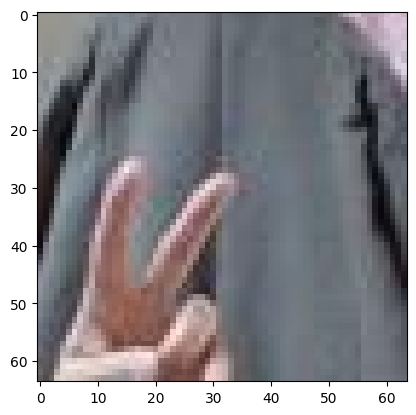

In [22]:
import matplotlib.pyplot as plt

plt.imshow(x_train[1000])
print('라벨: ', y_train[1000])

<br>

#### **데이터 준비 및 분리 (Split first)**

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [24]:
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_norm, y_train, test_size=0.2, random_state=42, shuffle=True
)

In [25]:
print("x_train_split shape: {}".format(x_train_split.shape))
print("y_train_split shape: {}".format(y_train_split.shape))
print("x_val_split shape: {}".format(x_val_split.shape))
print("y_val_split shape: {}".format(y_val_split.shape))

x_train_split shape: (2639, 64, 64, 3)
y_train_split shape: (2639,)
x_val_split shape: (660, 64, 64, 3)
y_val_split shape: (660,)


<br>

#### **딥러닝 네트워크 설계하기**

##### **오버피팅 극복 시도 1: 데이터 증강 (Diversity)**

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

##### **오버피팅 극복 시도 2: 모델 정규화 및 규제 (Regularization)**

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5), # 루브릭: 오버피팅 극복 시도 1
    tf.keras.layers.Dense(3, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,923 (6.20 MB)

 Trainable params: 1,625,731 (6.20 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# 낮은 학습률로 안정적 수렴 유도

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

##### **에폭 조절 및 최적 가중치 보존 (EarlyStopping)**

In [ ]:
# 최적 모델 복원 설정

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True # 가장 좋았던 val_loss 시점 가중치로 복구
)

<br>

#### **딥러닝 네트워크 학습시키기**

In [ ]:
# 모델 학습

In [ ]:
history = model.fit(
    train_datagen.flow(x_train_split, y_train_split, batch_size=32),
    validation_data=(x_val_split, y_val_split),
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


83/83 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.4169 - loss: 1.6802 - val_accuracy: 0.4106 - val_loss: 1.0612
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.5249 - loss: 1.0213 - val_accuracy: 0.5091 - val_loss: 1.0049
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.6144 - loss: 0.8549 - val_accuracy: 0.6364 - val_loss: 0.8502
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.6659 - loss: 0.7988 - val_accuracy: 0.5576 - val_loss: 0.8710
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.6583 - loss: 0.7640 - val_accuracy: 0.6561 - val_loss: 0.7372
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7249 - loss: 0.6512 - val_accuracy: 0.8061 - val_loss: 0.4839
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.7578 - loss: 0.6246 - val_accuracy: 0.8636 - val_loss: 0.3754
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.7301 - loss: 0.6223 - val_accuracy: 0.9000 - val_loss: 0

In [ ]:
# 결과 시각화

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy (Training vs Validation)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss (Training vs Validation)')
    plt.legend()
    plt.show()

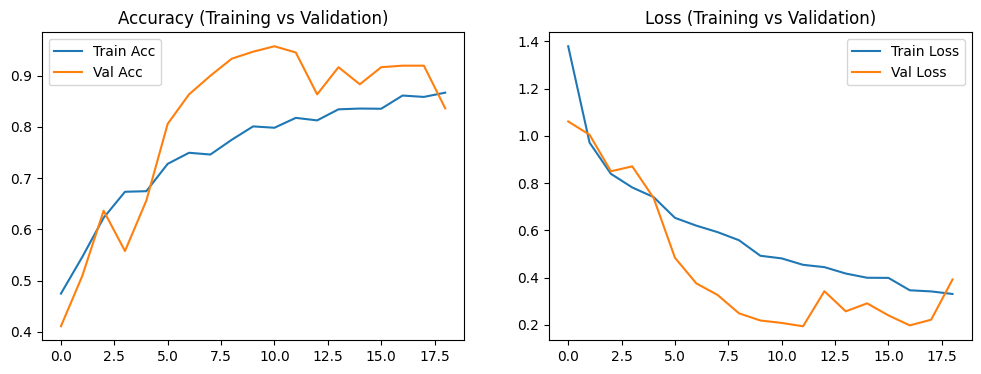

In [ ]:
plot_history(history)

<br>

#### **테스트 데이터 정확도 측정**

In [ ]:
# 테스트 데이터 전용 경로 설정
test_base_path = '/content/test'
test_zip_path = '/content/drive/MyDrive/DS_8th/08_딥러닝 알아보기/data/test.zip' # 드라이브 내 경로

In [ ]:
# 폴더 생성 및 압축 해제
if os.path.exists(test_zip_path):
    with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
        zip_ref.extractall(test_base_path)
    print("테스트 데이터 압축 해제 완료!")
else:
    print(f"파일을 찾을 수 없습니다: {test_zip_path}")

테스트 데이터 압축 해제 완료!


In [ ]:
image_dir_path = "/content/test/test/scissor/"
resize_images(image_dir_path)

print("가위 이미지 resize 완료!")

100  images in /content/test/test/scissor/ to be resized.
100  images resized.
가위 이미지 resize 완료!


In [ ]:
image_dir_path = "/content/test/test/rock/"
resize_images(image_dir_path)

print("바위 이미지 resize 완료!")

100  images in /content/test/test/rock/ to be resized.
100  images resized.
바위 이미지 resize 완료!


In [ ]:
image_dir_path = "/content/test/test/paper/"
resize_images(image_dir_path)

print("보 이미지 resize 완료!")

100  images in /content/test/test/paper/ to be resized.
100  images resized.
보 이미지 resize 완료!


<br>

실제 로드된 이미지 개수는 300 입니다.


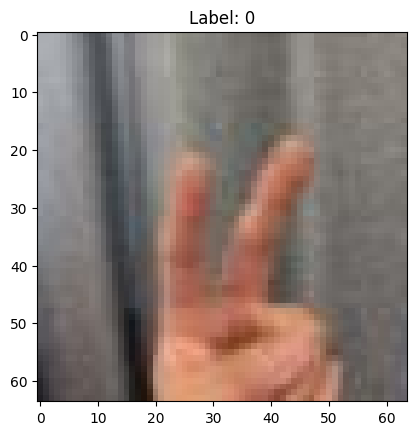

테스트 이미지 shape: (64, 64, 3)


In [ ]:
import matplotlib.pyplot as plt

# 테스트 데이터를 행렬(numpy array)로 불러오기
test_dir_path = "/content/test/test"
(x_test, y_test) = load_data(test_dir_path, number_of_data=300)

# 샘플 하나 확인 (첫 번째 이미지)
plt.imshow(x_test[0])
plt.title(f"Label: {y_test[0]}")
plt.show()

# 이미지의 실제 shape 확인
print(f"테스트 이미지 shape: {x_test[0].shape}")

In [ ]:
import numpy as np

def load_data(img_path, number_of_data=300):  # 총 개수 300로 설정
    # 가위 : 0, 바위 : 1, 보 : 2
    img_size=64
    color=3
    # 이미지 데이터와 라벨 데이터를 담을 빈 행렬을 만듬.
    imgs=np.zeros(number_of_data*img_size*img_size*color,dtype=np.int32).reshape(number_of_data,img_size,img_size,color)
    labels=np.zeros(number_of_data,dtype=np.int32)

    idx=0
    # 가위 폴더 읽기
    for file in glob.iglob(img_path+'/scissor/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img
        labels[idx]=0   # 가위는 0
        idx=idx+1

    # 바위 폴더 읽기
    for file in glob.iglob(img_path+'/rock/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img
        labels[idx]=1   # 바위는 1
        idx=idx+1

    # 보 폴더 읽기
    for file in glob.iglob(img_path+'/paper/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img
        labels[idx]=2   # 보는 2
        idx=idx+1

    print("학습데이터(x_test)의 이미지 개수는", idx,"입니다.")
    return imgs, labels

In [ ]:
image_dir_path = "/content/test/test"
(x_test, y_test)=load_data(image_dir_path, 300)
x_test_norm = x_test/255.0   # 0~1 사이로 정규화

print("x_train shape: {}".format(x_test.shape))
print("y_train shape: {}".format(y_test.shape))

학습데이터(x_test)의 이미지 개수는 300 입니다.
x_train shape: (300, 64, 64, 3)
y_train shape: (300,)


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test, verbose=2)
print("test_loss: {} ".format(test_loss))
print("test_accuracy: {}".format(test_accuracy))

10/10 - 0s - 44ms/step - accuracy: 0.7033 - loss: 0.6945
test_loss: 0.6945347785949707 
test_accuracy: 0.70333331823349


<br><br>

## **2-2. 프로젝트 제출**

---

#### **루브릭**

| 평가문항 | 상세기준 | 달성여부 |
| :--- | :--- | :---: |
| **1. 이미지 분류기 모델이 성공적으로 만들어졌는가?** | 학습과정이 정상적으로 수행되었으며, 학습 결과에 대한 그래프를 시각화(ex. train acc / train loss / val acc / val loss 등) 해 보았음 | **O** |
| **2. 오버피팅을 극복하기 위한 적절한 시도가 있었는가?** | 오버피팅 극복을 위하여 데이터셋의 다양성(Data Augmentation), 정규화(Dropout, Batch Normalization) 등을 2가지 이상 시도해보았음 | **O** |
| **3. 분류모델의 test accuracy가 기준 이상 높게 나왔는가?** | 최종 테스트 단계에서 **test accuracy 85% 이상** 도달하였음 | **70.3%** |